# Clustermap Analysis

## Overview
Use **hierarchical clustering** to reveal patterns in datasets by grouping similar rows and columns. Clustermaps automatically reorder rows and columns based on similarity, making patterns more visible.

## Key Concepts
- **Hierarchical Clustering**: Organizes data into a tree-like structure based on similarity
- **Heatmap**: Color-coded matrix showing actual values
- **Dendrograms**: Tree diagrams showing clustering relationships
- **Standard Scaling**: Normalizes data so all variables are on the same scale

In [ ]:
# Import Required Libraries
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Set a clean, professional plotting style for consistency
sns.set_theme(style="white", font_scale=1.0)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 100

In [ ]:
## Example 1: Clustermap with Iris Dataset

### Purpose
Cluster iris flowers based on their physical measurements. We'll identify which flowers are similar based on sepal/petal dimensions.

### What to Observe
- **Rows**: Individual iris flowers (reordered by similarity)
- **Columns**: Numeric features (sepal length/width, petal length/width)
- **Colors**: Value intensity (darker = larger values after scaling)
- **Left Dendrogram**: Shows which flowers cluster together
- **Top Dendrogram**: Shows which features are correlated

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


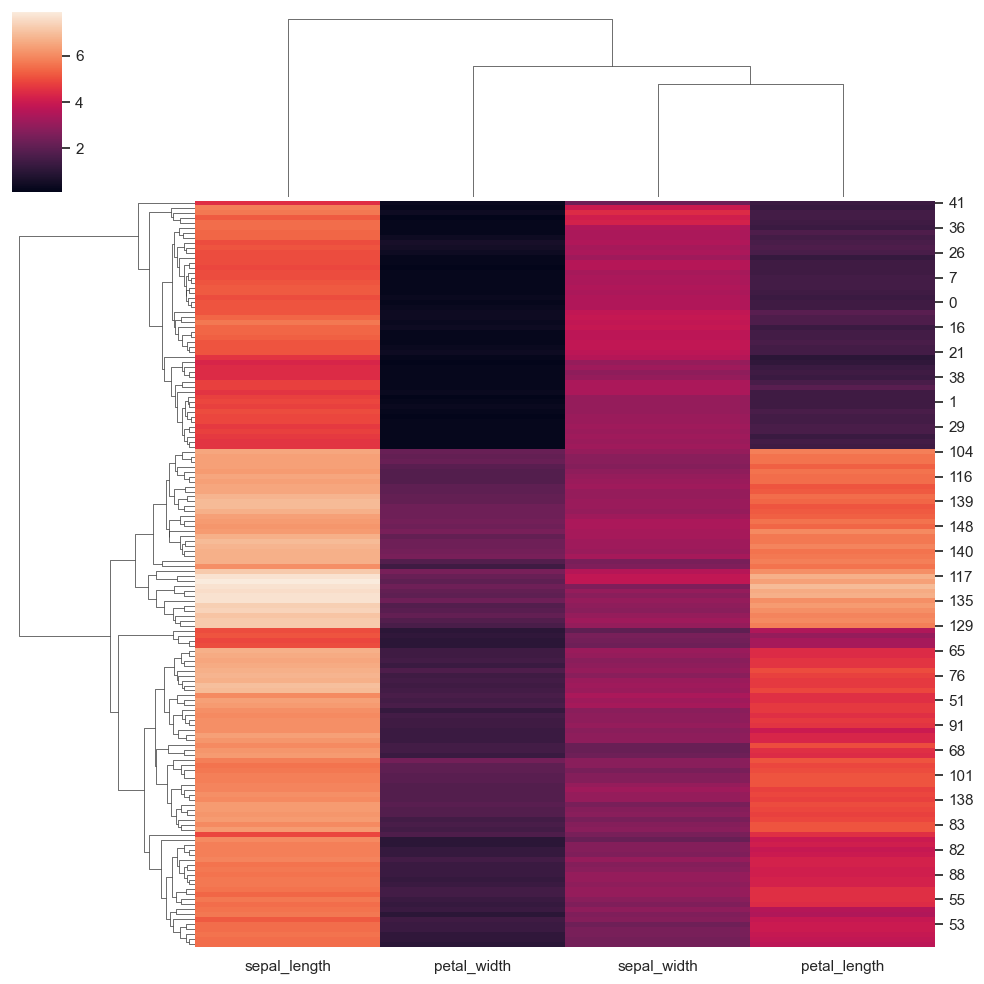

In [ ]:
# Load iris dataset
iris = sns.load_dataset("iris")

# Extract only numeric columns for clustering (exclude species category)
iris_num = iris.drop(columns="species")

# Create clustermap
g = sns.clustermap(
    iris_num, 
    cmap="viridis",           # Cool color scheme
    standard_scale=1,         # Normalize columns (scale 0-1)
    figsize=(9, 10),
    cbar_kws={'label': 'Normalized Value'},
    linewidths=0.5,
    linecolor='gray'
)

g.ax_heatmap.set_title('Iris Flowers Clustered by Features', fontsize=12, pad=20, fontweight='bold')
g.ax_heatmap.set_xlabel('Features', fontsize=11)
g.ax_heatmap.set_ylabel('Flowers (samples)', fontsize=11)

plt.tight_layout()
plt.show()

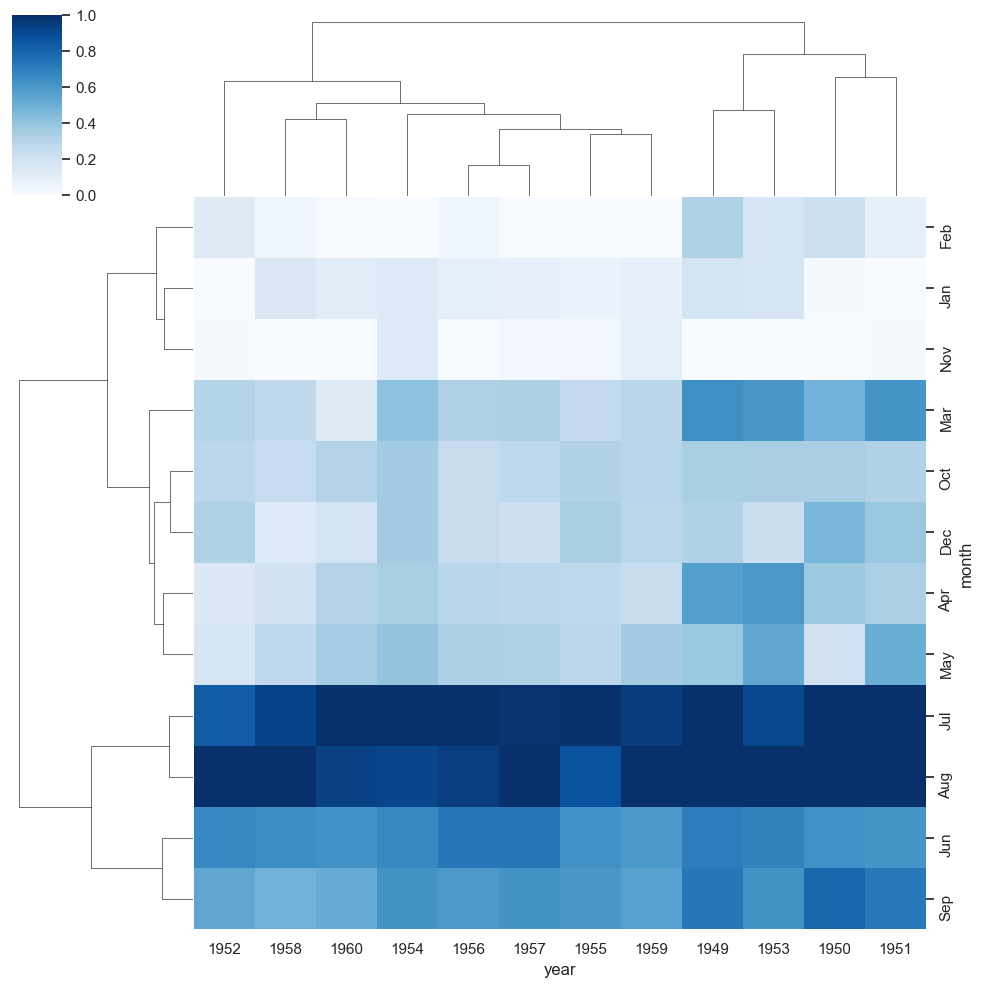

In [ ]:
## Example 2: Clustermap with Flights Dataset

### Purpose
Visualize passenger trends across months and years with hierarchical clustering. Identify seasonal patterns and which months/years have similar passenger behavior.

### Data Transformation
- Pivot the data to create a **matrix** (required for clustermap)
- Rows = Months, Columns = Years
- Values = Passenger counts

In [ ]:
# Load flights dataset
flights = sns.load_dataset("flights")

# Create pivot table - convert to matrix format (required for clustermap)
flights_pivot = flights.pivot_table(
    index="month",       # Rows
    columns="year",      # Columns
    values="passengers"  # Cell values
)

# Create clustermap
g = sns.clustermap(
    flights_pivot, 
    cmap="YlGnBu",           # Yellow-Green-Blue color scheme
    standard_scale=1,        # Normalize columns for fair comparison
    figsize=(11, 8),
    cbar_kws={'label': 'Passenger Count (normalized)'},
    linewidths=0.5,
    linecolor='white'
)

g.ax_heatmap.set_title('Passenger Trends Across Months & Years', fontsize=12, pad=20, fontweight='bold')
g.ax_heatmap.set_xlabel('Years', fontsize=11)
g.ax_heatmap.set_ylabel('Months', fontsize=11)

# Improve readability
g.ax_heatmap.tick_params(axis='x', rotation=45)
g.ax_heatmap.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()